## Adquisición y preprocesamiento de la información

<table>
    <tr>
      <td>Grado en Ingeniería de Datos e Inteligencia Artificial - Facultad de Informática - UCM
      </td>
      <td>
      <img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg"  width=50/>
      </td>
     </tr>
</table>




### Ejercicios - Tipos y Estadísticas básicas


Vamos a descargar datos de películas de la página IMDB. Se puede leer directamente con read_csv, pero hay que tener en cuenta que están separados por tabuladores (!)

In [2]:
url = "https://datasets.imdbws.com/title.basics.tsv.gz"
import pandas as pd

# solución
df_basics = pd.read_csv(url,delimiter="\t")
df_basics

D:\instalado\anacondainstalado\lib\site-packages\IPython\core\interactiveshell.py:3418: DtypeWarning: Columns (4) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"
...,...,...,...,...,...,...,...,...,...
9707255,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2010,\N,\N,"Action,Drama,Family"
9707256,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,"Action,Drama,Family"
9707257,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,"Action,Drama,Family"
9707258,tt9916856,short,The Wind,The Wind,0,2015,\N,27,Short


In [3]:
# lo primero miramos la información general
df_basics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9707260 entries, 0 to 9707259
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 666.5+ MB


Parece que habrá que trabajar un poco;  usar `describe` aquí no tiene mucho sentido desde el punto de vista estadístico pero nos puede ayudar a distinguir qué columnas son nominales u ordinales:

In [5]:
df_basics.describe()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
count,9707260,9707260,9707249,9707249,9707260,9707260,9707260,9707260,9707249
unique,9707260,11,4406370,4427918,12,153,96,886,2340
top,tt0000001,tvEpisode,Episode #1.1,Episode #1.1,0,\N,\N,\N,Drama
freq,1,7362015,47175,47175,9341437,1314693,9603131,6856823,1103295


¿Qué consecuencias sacamos sobre el tipo de cada columna? Escribir una breve frase en cada caso

* 'tconst': Identificador, nominal. No aporta información pero lo dejamos porque servirá para enlazar con otros ficheros
* 'titleType': 11 valores nominal. Merece un value_counts
* 'primaryTitle': Nominal
* 'originalTitle': Nominal
* 'isAdult': Nominal? 12 valores, . Merece un value_counts
* 'startYear': posiblemente numérico tipo intervalo pero vemos el valor "raro" \N ¿cambiarlo por NA?
* 'endYear': lo mismo que startYear
* 'runtimeMinutes': similar a las anteriores
* 'genres': ¿muchos géneros, no? Merece un value_counts

Empezamos reemplazando los \N por NA, la primera ventaja es que NA es de cuealqauier tipo y nos permitirá convertir a tipo numérico

In [68]:
import numpy as np
df_basics_nulos = df_basics.replace(r'\N', np.nan) # r al principio para que no interprete \ como carácter especial

In [69]:
df_basics_nulos.runtimeMinutes.unique()

array(['1', '5', '4', '12', '45', '2', nan, '0', '3', '100', '13', '6',
       '40', '11', '9', '10', '8', '15', '21', '16', '14', '7', '24',
       '17', '70', '90', '20', '25', '120', '36', '18', '30', '19', '44',
       '38', '58', '22', '33', '50', '34', '28', '35', '42', '23', '51',
       '52', '60', '92', '56', '26', '53', '31', '41', '48', '47', '68',
       '29', '71', '43', '46', '27', '32', '76', '85', '55', '150', '300',
       '121', '89', '37', '69', '54', '64', '96', '49', '61', '39', '101',
       '57', '99', '110', '88', '86', '170', '72', '78', '75', '450',
       '148', '80', '124', '220', '59', '63', '112', '1428', '84', '65',
       '74', '105', '310', '73', '82', '81', '199', '139', '109', '67',
       '219', '195', '440', '77', '293', '97', '79', '62', '66', '250',
       '421', '360', '180', '93', '163', '400', '95', '140', '165', '116',
       '83', '320', '125', '127', '138', '460', '350', '374', '480',
       '330', '91', '87', '130', '108', '136', '94', '600

Vamos a detectar valores no numéricos

In [70]:
filtro = df_basics_nulos.runtimeMinutes.str.isnumeric()
filtro

0          True
1          True
2          True
3          True
4          True
           ... 
9707255     NaN
9707256     NaN
9707257     NaN
9707258    True
9707259    True
Name: runtimeMinutes, Length: 9707260, dtype: object

Bienvenidos a la lógica trivaluada!!

In [71]:
filtro.value_counts()

True     2850426
False         11
Name: runtimeMinutes, dtype: int64

In [72]:
len(filtro)

9707260

In [73]:
len(df_basics_nulos[(filtro==False)]), len(df_basics_nulos[(filtro==True)]), len(df_basics_nulos[(filtro!=False)]),len(df_basics_nulos)

(11, 2850426, 9707249, 9707260)

Son muy pocos, tendríamos que investigar qué ocurre con estas fila (quizás esos \t en el título), pero decidimos borrarlos, escribir código para borrar estas 11 desafortunadas filas

In [74]:
# solución
df_basics_nulos2 = df_basics_nulos[(filtro!=False)]

In [75]:
df_basics_nulos2.runtimeMinutes.unique()

array(['1', '5', '4', '12', '45', '2', nan, '0', '3', '100', '13', '6',
       '40', '11', '9', '10', '8', '15', '21', '16', '14', '7', '24',
       '17', '70', '90', '20', '25', '120', '36', '18', '30', '19', '44',
       '38', '58', '22', '33', '50', '34', '28', '35', '42', '23', '51',
       '52', '60', '92', '56', '26', '53', '31', '41', '48', '47', '68',
       '29', '71', '43', '46', '27', '32', '76', '85', '55', '150', '300',
       '121', '89', '37', '69', '54', '64', '96', '49', '61', '39', '101',
       '57', '99', '110', '88', '86', '170', '72', '78', '75', '450',
       '148', '80', '124', '220', '59', '63', '112', '1428', '84', '65',
       '74', '105', '310', '73', '82', '81', '199', '139', '109', '67',
       '219', '195', '440', '77', '293', '97', '79', '62', '66', '250',
       '421', '360', '180', '93', '163', '400', '95', '140', '165', '116',
       '83', '320', '125', '127', '138', '460', '350', '374', '480',
       '330', '91', '87', '130', '108', '136', '94', '600

In [76]:
df_basics_nulos2.startYear.unique()

array(['1894', '1892', '1893', '1895', '1896', '1898', '1897', '1900',
       '1899', '1901', '1902', '1903', '1905', '1904', '1912', '1907',
       '1906', '1908', '1910', '1909', '1914', '1911', '1913', '1915',
       '1919', '1916', '1917', '1918', '1936', '1925', '1920', '1922',
       '1921', '1923', '1924', '1928', '2019', '2021', '1926', '1927',
       '1929', '2000', '1993', '1935', '1930', '1942', '1934', '1931',
       '1932', '1939', nan, '1937', '1933', '1950', '1938', '1951',
       '1945', '1946', '1940', '1944', '1949', '1947', '1941', '1952',
       '1970', '1957', '1943', '1959', '1948', '2001', '2016', '1953',
       '1954', '1965', '1983', '1980', '1973', '1961', '1995', '1955',
       '1962', '1958', '1956', '1977', '1960', '1964', '1967', '1968',
       '1963', '1986', '1971', '1969', '1972', '1966', '1976', '1990',
       '2020', '1979', '1974', '1978', '1981', '1988', '1975', '1989',
       '2014', '1985', '1987', '2010', '2018', '1984', '1982', '1992',
       '1

In [77]:
df_basics_nulos2.endYear.unique()

array([nan, '1947', '1945', '1955', '1949', '1958', '1951', '1950',
       '1952', '1954', '1957', '1953', '1956', '1967', '1971', '1959',
       '1963', '1960', '1961', '1965', '1980', '2016', '1986', '1962',
       '1972', '1966', '1970', '2009', '1973', '1987', '1968', '1997',
       '1974', '1992', '1976', '1975', '1982', '2010', '1984', '1964',
       '1989', '1969', '1994', '2004', '1981', '2003', '1999', '1988',
       '1985', '1977', '1978', '1993', '2001', '2013', '1996', '2011',
       '2005', '1995', '1979', '2006', '1983', '1990', '1998', '2008',
       '1991', '2020', '2007', '2022', '2018', '2015', '2014', '2021',
       '2000', '2019', '2023', '2002', '2017', '2012', '1948', '1938',
       '1925', '1942', '1933', '2024', '2026', '1944', '1946', '1937',
       '2028', '2025', '1906', '1941', '2027', '2030', '1939', '1932'],
      dtype=object)

Otra forma mejor: en lugar de borrar convertimos a [entero](https://stackoverflow.com/questions/15891038/change-column-type-in-pandas) startYear, endYear, runtimeMinutes; errors="coerce" hará que aunque haya valores incorrectos no haya problemas

In [85]:
df_basics_typed = df_basics_nulos.copy()
numéricas = ["startYear",  "endYear",  "runtimeMinutes"]

for c in numéricas:
    print(c)
    df_basics_typed[c] = pd.to_numeric(df_basics_nulos[c],errors='coerce').astype(pd.Int64Dtype())
    
df_basics_typed.dtypes    

startYear
endYear
runtimeMinutes


tconst            object
titleType         object
primaryTitle      object
originalTitle     object
isAdult           object
startYear          Int64
endYear            Int64
runtimeMinutes     Int64
genres            object
dtype: object

In [79]:
filtro = df_basics_nulos.runtimeMinutes.str.isnumeric()
df_basics_typed[(filtro==False)]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
1097571,tt10233364,tvEpisode,Rolling in the Deep Dish\tRolling in the Deep ...,0,2019,<NA>,<NA>,<NA>,NaN
1508259,tt10970874,tvEpisode,Die Bauhaus-Stadt Tel Aviv - Vorbild für die M...,0,2019,<NA>,<NA>,<NA>,NaN
1896279,tt11670006,tvEpisode,...ein angenehmer Unbequemer...\t...ein angene...,0,1981,<NA>,<NA>,<NA>,NaN
2007275,tt11868642,tvEpisode,GGN Heavyweight Championship Lungs With Mike T...,0,2020,<NA>,<NA>,<NA>,NaN
2161595,tt12149332,tvEpisode,Jeopardy! College Championship Semifinal Game ...,0,2020,<NA>,<NA>,<NA>,NaN
2306917,tt12415330,tvEpisode,Anthony Davis High Brow Tank\tAnthony Davis Hi...,0,2017,<NA>,<NA>,<NA>,NaN
2996368,tt13704268,tvEpisode,Bay of the Triffids/Doctor of Doom\tBay of the...,0,NaN,<NA>,<NA>,<NA>,NaN
6476205,tt27147391,tvEpisode,LATINO Accents QUIZ! w@MrHReviews @EchoBaseNet...,0,2023,<NA>,<NA>,<NA>,NaN
7029195,tt3984412,tvEpisode,"I'm Not Going to Come Last, I'm Just Going to ...",0,2014,<NA>,<NA>,<NA>,NaN
9663881,tt9822816,tvEpisode,Zwischen Vertuschung und Aufklärung - Missbrau...,0,2019,<NA>,<NA>,<NA>,NaN


¿Qué hacer con los géneros? pensarlo


In [80]:
df_basics_typed.genres.unique()

array(['Documentary,Short', 'Animation,Short', 'Animation,Comedy,Romance',
       ..., 'Biography,Crime,Music', 'Mystery,Reality-TV,Thriller',
       'Musical,Reality-TV,Talk-Show'], dtype=object)



## Parte 2

Utilizamos un segundo fichero que tiene ratings para las películas

In [81]:
url = "https://datasets.imdbws.com/title.ratings.tsv.gz"
df_ratings = pd.read_csv(url,delimiter="\t")
df_ratings

,tconst,averageRating,numVotes
0,tt0000001,5.7,1961
1,tt0000002,5.8,263
2,tt0000003,6.5,1799
3,tt0000004,5.6,179
4,tt0000005,6.2,2600
...,...,...,...
1292593,tt9916730,8.3,10
1292594,tt9916766,7.0,21
1292595,tt9916778,7.2,36
1292596,tt9916840,8.8,6


Hacer el histograma de las dos columnas y sacar consecuencias sobre curtosis y asimetría si tiene sentido

<Axes: >

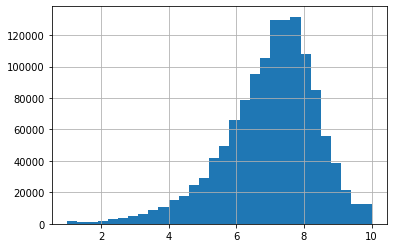

In [ ]:
# solución
df_ratings.averageRating.hist(bins=30)

<Axes: >

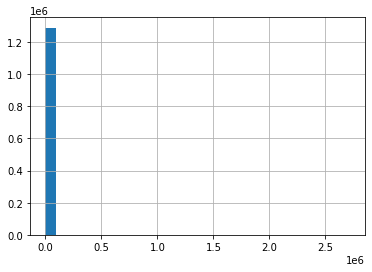

In [82]:
# solución
df_ratings.numVotes.hist(bins=30)

In [31]:
# solución
df_ratings.averageRating.skew()

-0.8023282742984923

In [32]:
# solución
df_ratings.averageRating.kurtosis()

1.1393795646722937

Dos tipos de gráficas muy sencillos pero útiles que debemos conocer son las gráficas de puntos (scatter) y de líneas (plot)

Pensar qué consecuencias se saca de la siguiente gráfica

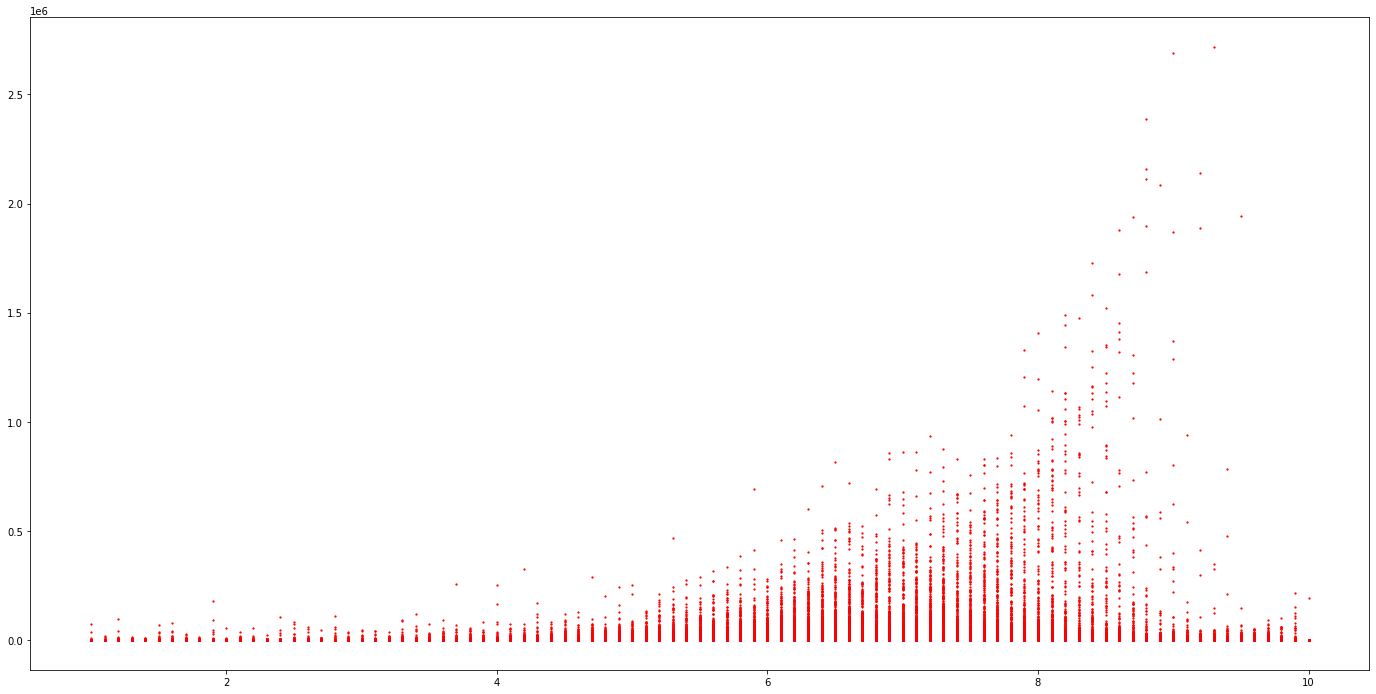

In [84]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(24, 12))
ax.scatter(df_ratings["averageRating"],df_ratings["numVotes"],s=1.5,c="red")
plt.show()
#df_ratings[["averageRating","numVotes"]].plot()

Calcular media, mediana, std, mad de estas dos columnas y extraer consecuencias

Escribir código para mezclar el df_ratings y df_basics_typed. Queremos quedarnos solo con las películas que tengan rating

In [89]:
# solución
comunes = pd.merge(df_basics_typed,df_ratings) 

De todas las películas (titleType=="movie") con al menos 10000 votos mostrar las que tienen mejor notal

In [90]:
df_pelis = comunes[(comunes.numVotes>=10000) & (comunes.titleType=="movie") ]
M = df_pelis.averageRating.max()
df_pelis[df_pelis.averageRating==M]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
747257,tt16747572,movie,The Silence of Swastika,The Silence of Swastika,0,2021,<NA>,56,"Documentary,History",9.6,10353


Lo mismo para la peor película

In [ ]:
# solución
m = df_pelis.averageRating.min()
df_pelis[df_pelis.averageRating==m]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
618478,tt13423846,movie,321 Action,321 Action,0,2020,\N,100,Drama,1.0,9724
665042,tt14446588,movie,Nyay: The Justice,Nyay: The Justice,0,2021,\N,110,Drama,1.0,1647
1122574,tt5988370,movie,Reis,Reis,0,2017,\N,108,"Biography,Drama",1.0,73743
1186495,tt7221896,movie,Cumali Ceber,Cumali Ceber: Allah Seni Alsin,0,2017,\N,100,Comedy,1.0,39153


Ahora queremos la peor película de tipo comedia 

In [ ]:
# solución
filtro = (comunes.numVotes>=1000) & (comunes.titleType=="movie") & comunes.genres.str.upper().str.contains("COMEDY")
df_comedy = comunes[filtro]
m = df_comedy.averageRating.min()
df_comedy[df_comedy.averageRating==m]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
1186495,tt7221896,movie,Cumali Ceber,Cumali Ceber: Allah Seni Alsin,0,2017,\N,100,Comedy,1.0,39153


La mejor y peor de todas las incluídas en comunes

In [93]:
# solución
M = comunes.numVotes.max()
comunes[comunes.numVotes==M]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
82427,tt0111161,movie,The Shawshank Redemption,The Shawshank Redemption,0,1994,<NA>,142,Drama,9.3,2716870
